# Lesson 04 — Dummy Variables (Categorical)

<h2 dir="rtl">פרק 1 — פתיחה ורענון משיעור 03</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pickle as pkl

<h2 dir="rtl">פרק 2 — מוטיבציה: השדה Factory</h2>

In [2]:
df = pkl.load(open('data_lesson_3.pkl', 'rb'))
df = df.rename(columns={'guidence': 'guidance', 'invsetment': 'investment'})
print(df['Factory'].value_counts())
df.head()

Factory
Ariel        44
Haifa        42
Jerusalem    39
Name: count, dtype: int64


,guidance,investment,accidents,Factory_num,intercept,Factory
0,0.0,0.00,345,1.0,1,Haifa
1,0.0,1.25,351,2.0,1,Jerusalem
2,0.0,2.50,348,1.0,1,Haifa
3,0.0,3.75,343,2.0,1,Jerusalem
4,0.0,5.00,337,0.0,1,Ariel


<h2 dir="rtl">פרק 3 — הדרך הנאיבית: Factory_num</h2>

In [3]:
X_naive = sm.add_constant(df[['guidance', 'investment', 'Factory_num']])
model_naive = sm.OLS(df['accidents'], X_naive).fit()
print(model_naive.summary())

                            OLS Regression Results                            
Dep. Variable:              accidents   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     3397.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          1.41e-116
Time:                        12:13:50   Log-Likelihood:                -293.05
No. Observations:                 125   AIC:                             594.1
Df Residuals:                     121   BIC:                             605.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         350.8181      0.635    552.284      

<h2 dir="rtl">פרק 4 — הדרך הנכונה: One-Hot Encoding</h2>

In [4]:
dummies = pd.get_dummies(df['Factory'], prefix='Factory', drop_first=True).astype(float)
X = pd.concat([df[['guidance', 'investment']], dummies], axis=1)
X = sm.add_constant(X)
model = sm.OLS(df['accidents'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              accidents   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     2554.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          4.68e-115
Time:                        12:13:50   Log-Likelihood:                -292.38
No. Observations:                 125   AIC:                             594.8
Df Residuals:                     120   BIC:                             608.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               350.5647      0.67

<h2 dir="rtl">פרק 5 — גיאומטריה: 3 קווים מקבילים</h2>

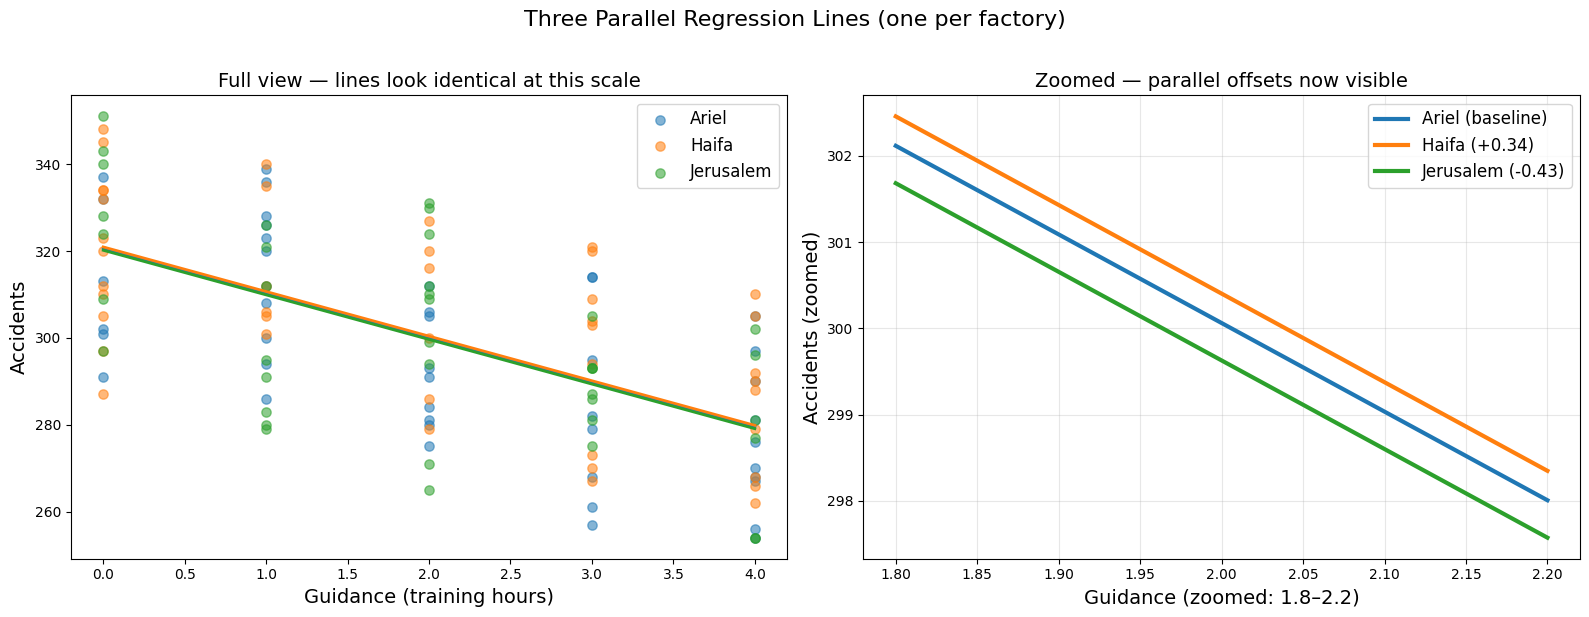

In [5]:
investment_mean = df['investment'].mean()
x_grid = np.linspace(df['guidance'].min(), df['guidance'].max(), 100)

b = model.params
intercept_ariel = b['const'] + b['investment'] * investment_mean
intercept_haifa = intercept_ariel + b['Factory_Haifa']
intercept_jeru  = intercept_ariel + b['Factory_Jerusalem']

fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(16, 6))

# Left: full data + 3 lines (lines look identical at this scale)
for factory, color in zip(['Ariel', 'Haifa', 'Jerusalem'], ['C0', 'C1', 'C2']):
    sub = df[df['Factory'] == factory]
    ax_full.scatter(sub['guidance'], sub['accidents'], label=factory, color=color, alpha=0.55, s=45)

ax_full.plot(x_grid, intercept_ariel + b['guidance'] * x_grid, color='C0', lw=2)
ax_full.plot(x_grid, intercept_haifa + b['guidance'] * x_grid, color='C1', lw=2)
ax_full.plot(x_grid, intercept_jeru  + b['guidance'] * x_grid, color='C2', lw=2)
ax_full.set_xlabel('Guidance (training hours)', fontsize=14)
ax_full.set_ylabel('Accidents', fontsize=14)
ax_full.set_title('Full view — lines look identical at this scale', fontsize=14)
ax_full.legend(fontsize=12)

# Right: zoom around guidance=2 to make parallel offsets visible
zoom_x = np.linspace(1.8, 2.2, 50)
ax_zoom.plot(zoom_x, intercept_ariel + b['guidance'] * zoom_x, color='C0', lw=3, label='Ariel (baseline)')
ax_zoom.plot(zoom_x, intercept_haifa + b['guidance'] * zoom_x, color='C1', lw=3, label='Haifa (+0.34)')
ax_zoom.plot(zoom_x, intercept_jeru  + b['guidance'] * zoom_x, color='C2', lw=3, label='Jerusalem (-0.43)')
ax_zoom.set_xlabel('Guidance (zoomed: 1.8–2.2)', fontsize=14)
ax_zoom.set_ylabel('Accidents (zoomed)', fontsize=14)
ax_zoom.set_title('Zoomed — parallel offsets now visible', fontsize=14)
ax_zoom.legend(fontsize=12, loc='upper right')
ax_zoom.grid(alpha=0.3)

plt.suptitle('Three Parallel Regression Lines (one per factory)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

<h2 dir="rtl">פרק 6 — Dummy Trap</h2>

In [6]:
dummies_all = pd.get_dummies(df['Factory'], prefix='Factory', drop_first=False).astype(float)
X_trap = pd.concat([df[['guidance', 'investment']], dummies_all], axis=1)
X_trap = sm.add_constant(X_trap)

print(f'Rank of X = {np.linalg.matrix_rank(X_trap.values)}, columns = {X_trap.shape[1]}')

model_trap = sm.OLS(df['accidents'], X_trap).fit()
print(model_trap.summary().tables[1])
print(f'R^2 = {model_trap.rsquared:.4f}')

Rank of X = 5, columns = 6
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               262.9004      0.416    631.425      0.000     262.076     263.725
guidance            -10.2714      0.162    -63.294      0.000     -10.593      -9.950
investment           -1.9974      0.026    -77.636      0.000      -2.048      -1.946
Factory_Ariel        87.6644      0.365    239.862      0.000      86.941      88.388
Factory_Haifa        88.0054      0.340    259.156      0.000      87.333      88.678
Factory_Jerusalem    87.2306      0.359    242.969      0.000      86.520      87.941
R^2 = 0.9884


<h2 dir="rtl">פרק 7 — F-test משותף</h2>

In [7]:
X_reduced = sm.add_constant(df[['guidance', 'investment']])
model_reduced = sm.OLS(df['accidents'], X_reduced).fit()

f_stat, p_val, df_diff = model.compare_f_test(model_reduced)
print(f'F = {f_stat:.4f}')
print(f'p = {p_val:.4f}')
print(f'df_diff = {df_diff}')

F = 0.9225
p = 0.4003
df_diff = 2.0


<h2 dir="rtl">פרק 8 — סגירה</h2>

### Write your answer here.

<div dir="rtl">חזו ידנית את מספר התאונות הצפוי למפעל <b>בירושלים</b> עם <code>guidance = 3</code> ו-<code>investment = 20</code>, על בסיס המקדמים מ-<code>model.summary()</code>. בדקו שמתקבל אותו ערך כמו ב-<code>model.predict()</code> עם הוקטור <code>[1, 3, 20, 0, 1]</code>.</div>